In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from numpy.linalg import lstsq
from scipy.optimize import curve_fit

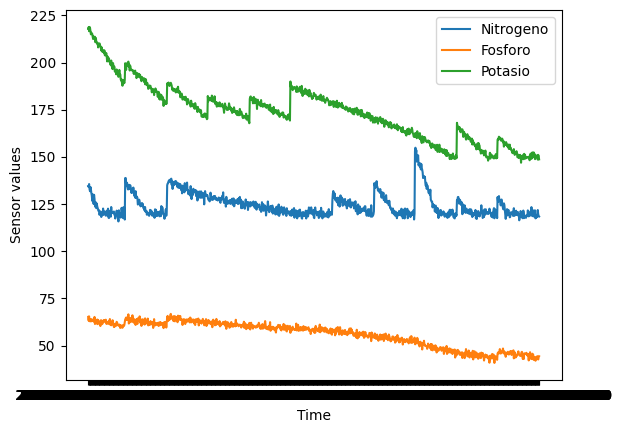

In [180]:
# Read data_sensores.csv
data_sensores = pd.read_csv('data_sensores.csv')

# Graph with time in x-axis and sensor values in y-axis (over time) (only the last 200 values)
plt.plot(data_sensores['FechaHora'][-1000:], data_sensores['Nitrogeno'][-1000:], label='Nitrogeno')
plt.plot(data_sensores['FechaHora'][-1000:], data_sensores['Fosforo'][-1000:], label='Fosforo')
plt.plot(data_sensores['FechaHora'][-1000:], data_sensores['Potasio'][-1000:], label='Potasio')
plt.xlabel('Time')
plt.ylabel('Sensor values')
plt.legend()
plt.show()


In [181]:
# Guardar en una lista los valores de nitrogeno con su respectivo tiempo
nitrogeno = data_sensores['Nitrogeno'].values
fosforo = data_sensores['Fosforo'].values
tiempo = data_sensores['FechaHora'].values


# Polinomial Regression

254


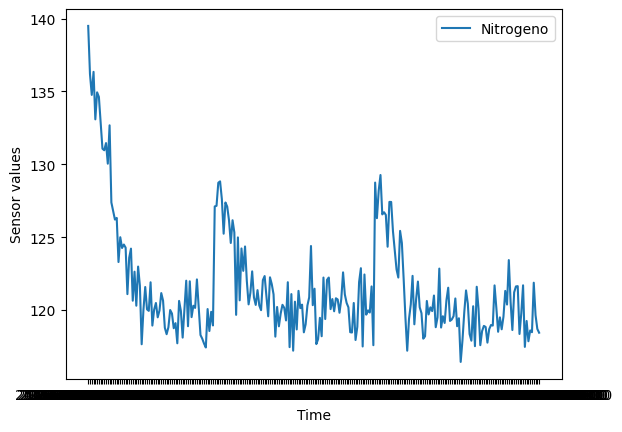

In [182]:
# Intentar con solo hacer la prediccion desde la ultima fertilizacion

# Obtener diferencia del tiempo entre la ultima fertilizacion y la fecha actual
datosDesdeUltimaFertilizacionTIEMPO = []
datosDesdeUltimaFertilizacionNITROGENO = []

# Recorrer el dataframe de ultima fecha hacia atras, para obtener los datos desde la ultima fertilizacion
for i in range(len(nitrogeno) - 1, 0, -1):
    # Calcular la media y desviación estándar de los datos anteriores
    datos_anteriores = nitrogeno[:i]
    media = np.mean(datos_anteriores)
    desviacion_estandar = np.std(datos_anteriores)
    
    # Verificar si el dato actual se aleja significativamente, si se aleja, entonces se considera el inicio de la fertilizacion
    if abs(nitrogeno[i] - media) > 1 * desviacion_estandar:
        # Obtener los datos desde la ultima fertilizacion
        datosDesdeUltimaFertilizacionTIEMPO = tiempo[i:]
        datosDesdeUltimaFertilizacionNITROGENO = nitrogeno[i:]
        break
    

print(len(datosDesdeUltimaFertilizacionNITROGENO))


# Graficar los datos desde la ultima fertilizacion
plt.plot(datosDesdeUltimaFertilizacionTIEMPO, datosDesdeUltimaFertilizacionNITROGENO, label='Nitrogeno')
plt.xlabel('Time')
plt.ylabel('Sensor values')
plt.legend()
plt.show()



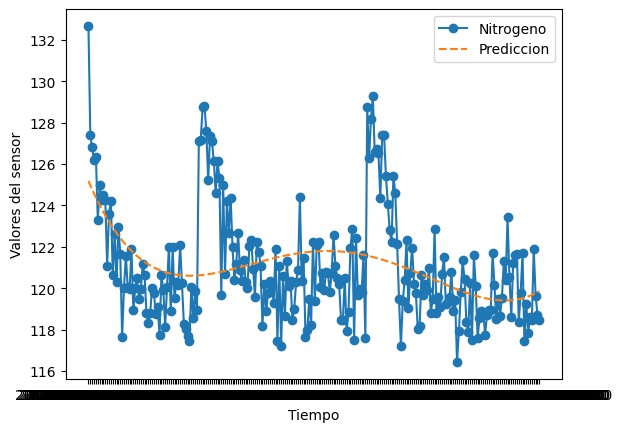

In [183]:
# Utilizando los datos desde la ultima fertilizacion, realizar una regresion polinomial de grado 3

# Eliminar los primeros 12 datos de datosDesdeUltimaFertilizacionTIEMPO y datosDesdeUltimaFertilizacionNUTRIENTES
datosDesdeUltimaFertilizacionTIEMPO = datosDesdeUltimaFertilizacionTIEMPO[12:]
datosDesdeUltimaFertilizacionNITROGENO = datosDesdeUltimaFertilizacionNITROGENO[12:]

# Convertir los datos de tiempo a números
datosDesdeUltimaFertilizacionTIEMPO_NUMEROS = np.arange(len(datosDesdeUltimaFertilizacionTIEMPO))

# Transformar los datos para regresión polinomial de grado 3
poly_features = PolynomialFeatures(degree=4)
tiempo_poly = poly_features.fit_transform(datosDesdeUltimaFertilizacionTIEMPO_NUMEROS.reshape(-1, 1))

# Hacer regresión polinomial
regression = LinearRegression()
regression.fit(tiempo_poly, datosDesdeUltimaFertilizacionNITROGENO)

# Predecir los datos
prediccion = regression.predict(tiempo_poly)

# Mostrar la predicción de los datos
plt.plot(datosDesdeUltimaFertilizacionTIEMPO, datosDesdeUltimaFertilizacionNITROGENO, label='Nitrogeno', marker='o')
plt.plot(datosDesdeUltimaFertilizacionTIEMPO, prediccion, label='Prediccion', linestyle='--')
plt.xlabel('Tiempo')
plt.ylabel('Valores del sensor')
plt.legend()
plt.show()

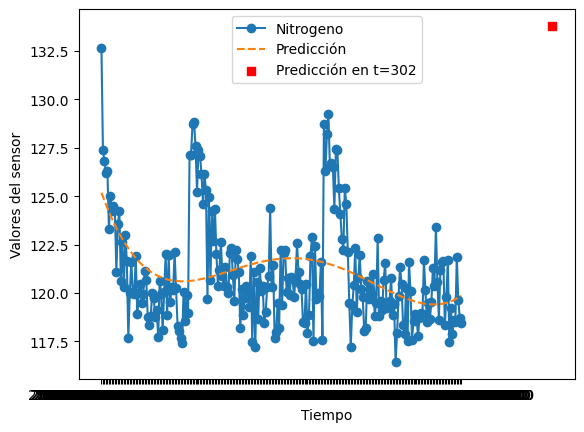

In [195]:
# Convertir los datos de tiempo a números
datosDesdeUltimaFertilizacionTIEMPO_NUMEROS = np.arange(len(datosDesdeUltimaFertilizacionTIEMPO))

# Transformar los datos para regresión polinomial de grado 4 (o grado 3 si decides ajustar con grado 3)
poly_features = PolynomialFeatures(degree=4)
tiempo_poly = poly_features.fit_transform(datosDesdeUltimaFertilizacionTIEMPO_NUMEROS.reshape(-1, 1))

# Hacer regresión polinomial
regression = LinearRegression()
regression.fit(tiempo_poly, datosDesdeUltimaFertilizacionNITROGENO)

# Predecir valores en el tiempo futuro
# Supongamos que queremos predecir el valor en el tiempo 21
tiempo_futuro = len(datosDesdeUltimaFertilizacionTIEMPO_NUMEROS) + 60
tiempo_futuro_numero = np.array([tiempo_futuro])
tiempo_futuro_poly = poly_features.transform(tiempo_futuro_numero.reshape(-1, 1))
prediccion_futuro = regression.predict(tiempo_futuro_poly)

# Mostrar la predicción de los datos
plt.plot(datosDesdeUltimaFertilizacionTIEMPO, datosDesdeUltimaFertilizacionNITROGENO, label='Nitrogeno', marker='o')
plt.plot(datosDesdeUltimaFertilizacionTIEMPO, regression.predict(tiempo_poly), label='Predicción', linestyle='--')

# Agregar la predicción para el tiempo futuro
plt.scatter(tiempo_futuro, prediccion_futuro, color='red', marker='s', label=f'Predicción en t={tiempo_futuro}')

plt.xlabel('Tiempo')
plt.ylabel('Valores del sensor')
plt.legend()
plt.show()